## MSc Artificial Intelligence - Masters Project

## Farah Iqbal - S08431208

# Machine Learning Model Development and Benchmarking

## Research Objective

The purpose of this notebook is to develop, evaluate and compare multiple machine learning classification models for predicting disability severity in Multiple Sclerosis using the multimodal dataset created in Notebook 3.

Due to the limited number of patients within the original High disability category (n = 2), the Moderate and High disability groups have been combined to create a binary classification problem. This reduces the impact of severe class imbalance while maintaining the project's objective of distinguishing patients with lower versus greater disability severity.

Several machine learning algorithms will be benchmarked using clinical features, MRI-derived biomarkers and the combined multimodal dataset. Cross-validation and hyperparameter optimisation will then be performed to identify the best-performing model.

The selected model will subsequently be used within the explainability stage of the project, where SHAP, LIME and the proposed Agentic AI framework will be compared.

## Notebook 4 Structure

- Load the multimodal dataset
- Create the binary disability target
- Prepare the modelling datasets
- Explore class balance
- Split the data into training and testing sets
- Standardise numerical features
- Train baseline classification models
- Evaluate model performance
- Perform Stratified K-Fold Cross Validation
- Compare model performance
- Perform Hyperparameter Optimisation
- Select the best-performing model
- Export the trained model

Import Required Libraries

In [ ]:
import os
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate,
    GridSearchCV,
    RandomizedSearchCV
)

from sklearn.preprocessing import StandardScaler

from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)

from sklearn.svm import SVC

from xgboost import XGBClassifier

import joblib

pd.set_option("display.max_columns", None)

plt.rcParams["figure.figsize"] = (8,5)

Mount Google Drive

In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


Cell 4: Define Dataset Path

In [ ]:
dataset_path = "/content/drive/MyDrive/MS_Dissertation/Outputs/multimodal_dataset.csv"

print("Dataset exists:", os.path.exists(dataset_path))

Dataset exists: True


Cell 5: Load the Multimodal Dataset

In [ ]:
multimodal_df = pd.read_csv(dataset_path)

print(multimodal_df.shape)

multimodal_df.head()

(60, 41)


,Patient_ID,Gender,Age,Age_of_onset,EDSS,MRI_EDSS_Time_Difference_Under_2_Months,Types_of_Medicines,Presenting_Symptom,Co_morbidity,Pyramidal,Cerebella,Brain_stem,Sensory,Sphincters,Visual,Mental,Speech,Motor_System,Sensory_System,Coordination,Gait,Bowel_and_bladder_function,Mobility,Mental_State,Optic_discs,Fields,Nystagmus,Ocular_Movement,Swallowing,Disease_Duration,EDSS_Category,Total_Abnormal_Neuro_Findings,Lesion_Voxels,Lesion_Volume_mm3,Lesion_Count,Average_Lesion_Size,Largest_Lesion_Size,Smallest_Lesion_Size,Small_Lesions,Medium_Lesions,Large_Lesions
0,1,F,56,43,3.0,No,Gelenia,Motor,No,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,1,0,1,0,0,13,Moderate,4,776,776.0,52,14.923077,68,2,25,26,1
1,2,F,29,19,1.5,No,Gelenia,Sensory,No,0,0,0,0,0,0,0,0,1,1,0,0,0,1,0,0,0,0,0,0,10,Low,3,2485,2485.0,33,75.303030,629,6,4,20,9
2,3,F,15,8,4.0,No,Tysabri,Motor,No,1,1,0,0,0,1,0,0,1,0,1,0,0,0,0,1,0,0,0,0,7,Moderate,6,2273,2273.0,65,34.969231,188,1,14,35,16
3,4,F,24,20,6.0,No,Tysabri,Sensory,No,1,1,1,0,1,0,0,0,1,0,1,1,0,0,0,0,0,0,0,0,4,High,7,4906,4906.0,21,233.619048,2194,3,6,9,6
4,5,F,33,31,0.0,No,Avonex,Pain,No,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,2,Low,1,2109,2109.0,59,35.745763,257,5,9,39,11


## Explore the Multimodal Dataset

Before developing machine learning models, the multimodal dataset is inspected to verify that all variables have been loaded correctly. This provides an overview of the dataset structure and confirms that the clinical variables and MRI-derived biomarkers are available for modelling.

Cell 7: Display Dataset Information

In [ ]:
print(multimodal_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 41 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   Patient_ID                               60 non-null     int64  
 1   Gender                                   60 non-null     object 
 2   Age                                      60 non-null     int64  
 3   Age_of_onset                             60 non-null     int64  
 4   EDSS                                     60 non-null     float64
 5   MRI_EDSS_Time_Difference_Under_2_Months  60 non-null     object 
 6   Types_of_Medicines                       60 non-null     object 
 7   Presenting_Symptom                       60 non-null     object 
 8   Co_morbidity                             60 non-null     object 
 9   Pyramidal                                60 non-null     int64  
 10  Cerebella                                60 non-null

Cell 8: Generate Summary Statistics

In [ ]:
multimodal_df.describe()

,Patient_ID,Age,Age_of_onset,EDSS,Pyramidal,Cerebella,Brain_stem,Sensory,Sphincters,Visual,Mental,Speech,Motor_System,Sensory_System,Coordination,Gait,Bowel_and_bladder_function,Mobility,Mental_State,Optic_discs,Fields,Nystagmus,Ocular_Movement,Swallowing,Disease_Duration,Total_Abnormal_Neuro_Findings,Lesion_Voxels,Lesion_Volume_mm3,Lesion_Count,Average_Lesion_Size,Largest_Lesion_Size,Smallest_Lesion_Size,Small_Lesions,Medium_Lesions,Large_Lesions
count,60.000000,60.0000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.0,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.00000,60.000000,60.000000,60.000000,60.000000
mean,30.500000,32.6500,29.766667,2.266667,0.516667,0.283333,0.083333,0.300000,0.150000,0.283333,0.033333,0.100000,0.583333,0.316667,0.283333,0.283333,0.150000,0.066667,0.050000,0.366667,0.0,0.116667,0.033333,0.050000,2.883333,4.050000,8086.083333,8086.083333,44.233333,206.022490,2455.15000,5.083333,9.916667,17.783333,16.533333
std,17.464249,12.1304,11.009036,1.595722,0.503939,0.454420,0.278718,0.462125,0.360085,0.454420,0.181020,0.302532,0.497167,0.469102,0.454420,0.454420,0.360085,0.251549,0.219784,0.485961,0.0,0.323732,0.181020,0.219784,4.239010,2.389419,12724.711405,12724.711405,41.387940,306.784186,5080.93112,13.754866,24.041836,17.936887,16.868853
min,1.000000,15.0000,8.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,-2.000000,0.000000,324.000000,324.000000,2.000000,7.653509,47.00000,1.000000,0.000000,0.000000,0.000000
25%,15.750000,20.0000,19.750000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,2.000000,1741.250000,1741.250000,21.750000,49.717672,307.50000,1.000000,2.000000,7.750000,7.000000
50%,30.500000,33.0000,30.500000,2.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,1.500000,4.000000,3300.500000,3300.500000,32.500000,100.423828,625.00000,2.000000,4.500000,14.000000,12.000000
75%,45.250000,42.2500,40.000000,3.500000,1.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.0,0.000000,0.000000,0.000000,4.000000,6.000000,7703.250000,7703.250000,51.250000,240.754831,1972.00000,4.000000,8.000000,20.250000,17.250000
max,60.000000,56.0000,52.000000,6.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.0,1.000000,1.000000,1.000000,21.000000,10.000000,60999.000000,60999.000000,228.000000,1783.259259,29363.00000,104.000000,178.000000,111.000000,101.000000


## Create the Binary Disability Target

The original EDSS disability categories are converted into a binary classification target.

- Low Disability = 0
- Moderate and High Disability = 1

This approach reduces severe class imbalance whilst maintaining a clinically meaningful prediction task.

Cell 10: Create Binary Disability Variable

In [ ]:
multimodal_df["Binary_Disability"] = multimodal_df["EDSS_Category"].map({
    "Low": 0,
    "Moderate": 1,
    "High": 1
}).astype(int)

multimodal_df[
    [
        "EDSS",
        "EDSS_Category",
        "Binary_Disability"
    ]
].head()

,EDSS,EDSS_Category,Binary_Disability
0,3.0,Moderate,1
1,1.5,Low,0
2,4.0,Moderate,1
3,6.0,High,1
4,0.0,Low,0


Cell 11: Examine Binary Class Distribution

In [ ]:
multimodal_df["Binary_Disability"].value_counts()

,count
Binary_Disability,
0,35
1,25


Cell 12: Visualise Class Distribution

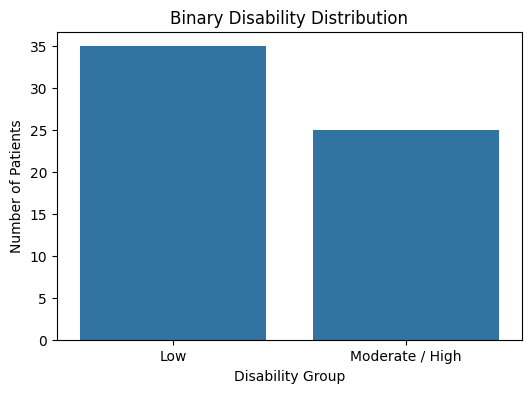

In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=multimodal_df,
    x="Binary_Disability"
)

plt.xticks([0,1],["Low","Moderate / High"])

plt.title("Binary Disability Distribution")

plt.xlabel("Disability Group")

plt.ylabel("Number of Patients")

plt.show()

## Prepare the Modelling Dataset

The predictor variables and target variable are separated before model development.

Variables that could introduce data leakage, such as patient identifiers and the original EDSS measurements, are removed prior to training.

Cell 14: Separate Features and Target Variable

In [ ]:
columns_to_remove = [

    "Patient_ID",

    "EDSS",

    "EDSS_Category",

    "Binary_Disability"

]

X = multimodal_df.drop(columns=columns_to_remove)

y = multimodal_df["Binary_Disability"]

print("Feature Matrix:", X.shape)

print("Target Vector:", y.shape)

print("\nFeature Names:\n")

for col in X.columns:
    print(col)

Feature Matrix: (60, 38)
Target Vector: (60,)

Feature Names:

Gender
Age
Age_of_onset
MRI_EDSS_Time_Difference_Under_2_Months
Types_of_Medicines
Presenting_Symptom
Co_morbidity
Pyramidal
Cerebella
Brain_stem
Sensory
Sphincters
Visual
Mental
Speech
Motor_System
Sensory_System
Coordination
Gait
Bowel_and_bladder_function
Mobility
Mental_State
Optic_discs
Fields
Nystagmus
Ocular_Movement
Swallowing
Disease_Duration
Total_Abnormal_Neuro_Findings
Lesion_Voxels
Lesion_Volume_mm3
Lesion_Count
Average_Lesion_Size
Largest_Lesion_Size
Smallest_Lesion_Size
Small_Lesions
Medium_Lesions
Large_Lesions


## Data Cleaning and Feature Preparation

Before training machine learning models, the predictor variables are cleaned and prepared. This includes removing variables that could introduce data leakage, correcting inconsistencies within categorical variables and encoding categorical features into a numerical format suitable for machine learning algorithms.

These steps improve data quality and help ensure that model performance reflects meaningful clinical and MRI-derived information rather than inconsistencies in the raw dataset.

Cell 17: Remove Non-Predictive Features

In [ ]:
# Remove variables that should not be used for prediction

columns_to_remove = [

    "Patient_ID",
    "EDSS",
    "EDSS_Category",
    "Binary_Disability",
    "MRI_EDSS_Time_Difference_Under_2_Months",
    "Lesion_Voxels"

]

X = multimodal_df.drop(columns=columns_to_remove).copy()

y = multimodal_df["Binary_Disability"].copy()

print("Feature Matrix Shape:", X.shape)
print("Target Vector Shape:", y.shape)

Feature Matrix Shape: (60, 36)
Target Vector Shape: (60,)


Cell 18: Clean Categorical Variables

In [ ]:
# Create a copy before cleaning
X_clean = X.copy()

# -------------------------------------------------
# Gender
# -------------------------------------------------

# Replace invalid gender code with missing value
X_clean["Gender"] = X_clean["Gender"].replace("N", np.nan)

# Impute using the most frequent category
X_clean["Gender"] = X_clean["Gender"].fillna(
    X_clean["Gender"].mode()[0]
)

# -------------------------------------------------
# Presenting Symptoms
# -------------------------------------------------

X_clean["Presenting_Symptom"] = (
    X_clean["Presenting_Symptom"]
    .str.strip()
    .str.replace("&Motor", "& Motor", regex=False)
    .str.replace("&Visual", "& Visual", regex=False)
    .str.replace("Motore", "Motor", regex=False)
)

# Remove repeated spaces
X_clean["Presenting_Symptom"] = (
    X_clean["Presenting_Symptom"]
    .str.replace(r"\s+", " ", regex=True)
)

print("Cleaning complete.")

Cleaning complete.


Cell 19: Verify Cleaned Categories

In [ ]:
print("Gender Categories\n")
print(X_clean["Gender"].value_counts())

print("\n")

print("Presenting Symptom Categories\n")
print(sorted(X_clean["Presenting_Symptom"].unique()))

Gender Categories

Gender
F    47
M    13
Name: count, dtype: int64


Presenting Symptom Categories

['Balance', 'Balance & Motor', 'Motor', 'Motor & Behavioural', 'Motor & Sensory', 'Motor & Visual', 'Pain', 'Sensory', 'Sensory & Motor', 'Sensory & Visual', 'Sensory & Visual ,Balance , Motor, Sexual,Fatigue', 'Visual', 'Visual & Balance']


### Data Cleaning Summary

The categorical variables were reviewed before model development.

One invalid value within the Gender variable was identified and imputed using the mode of the variable.

Minor inconsistencies within the Presenting Symptom variable (for example spelling and spacing differences) were standardised to improve category consistency before one-hot encoding.

These preprocessing steps improve data quality while preserving the clinical information contained within the original dataset.

Cell 20: One-Hot Encode Categorical Variables

In [ ]:
X_encoded = pd.get_dummies(

    X_clean,

    drop_first=True,

    dtype=int

)

print("Encoded Dataset Shape:", X_encoded.shape)

X_encoded.head()

Encoded Dataset Shape: (60, 50)


,Age,Age_of_onset,Pyramidal,Cerebella,Brain_stem,Sensory,Sphincters,Visual,Mental,Speech,Motor_System,Sensory_System,Coordination,Gait,Bowel_and_bladder_function,Mobility,Mental_State,Optic_discs,Fields,Nystagmus,Ocular_Movement,Swallowing,Disease_Duration,Total_Abnormal_Neuro_Findings,Lesion_Volume_mm3,Lesion_Count,Average_Lesion_Size,Largest_Lesion_Size,Smallest_Lesion_Size,Small_Lesions,Medium_Lesions,Large_Lesions,Gender_M,Types_of_Medicines_Betaferon,Types_of_Medicines_Gelenia,Types_of_Medicines_Rebif,Types_of_Medicines_Tysabri,Presenting_Symptom_Balance & Motor,Presenting_Symptom_Motor,Presenting_Symptom_Motor & Behavioural,Presenting_Symptom_Motor & Sensory,Presenting_Symptom_Motor & Visual,Presenting_Symptom_Pain,Presenting_Symptom_Sensory,Presenting_Symptom_Sensory & Motor,Presenting_Symptom_Sensory & Visual,"Presenting_Symptom_Sensory & Visual ,Balance , Motor, Sexual,Fatigue",Presenting_Symptom_Visual,Presenting_Symptom_Visual & Balance,Co_morbidity_Yes
0,56,43,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,1,0,1,0,0,13,4,776.0,52,14.923077,68,2,25,26,1,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0
1,29,19,0,0,0,0,0,0,0,0,1,1,0,0,0,1,0,0,0,0,0,0,10,3,2485.0,33,75.303030,629,6,4,20,9,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0
2,15,8,1,1,0,0,0,1,0,0,1,0,1,0,0,0,0,1,0,0,0,0,7,6,2273.0,65,34.969231,188,1,14,35,16,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0
3,24,20,1,1,1,0,1,0,0,0,1,0,1,1,0,0,0,0,0,0,0,0,4,7,4906.0,21,233.619048,2194,3,6,9,6,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0
4,33,31,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,2,1,2109.0,59,35.745763,257,5,9,39,11,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0


Cell 21: Inspect Encoded Dataset

In [ ]:
print("Number of Features:", X_encoded.shape[1])

print("\n")

print("Feature Names:\n")

for feature in X_encoded.columns:
    print(feature)

Number of Features: 50


Feature Names:

Age
Age_of_onset
Pyramidal
Cerebella
Brain_stem
Sensory
Sphincters
Visual
Mental
Speech
Motor_System
Sensory_System
Coordination
Gait
Bowel_and_bladder_function
Mobility
Mental_State
Optic_discs
Fields
Nystagmus
Ocular_Movement
Swallowing
Disease_Duration
Total_Abnormal_Neuro_Findings
Lesion_Volume_mm3
Lesion_Count
Average_Lesion_Size
Largest_Lesion_Size
Smallest_Lesion_Size
Small_Lesions
Medium_Lesions
Large_Lesions
Gender_M
Types_of_Medicines_Betaferon
Types_of_Medicines_Gelenia
Types_of_Medicines_Rebif
Types_of_Medicines_Tysabri
Presenting_Symptom_Balance & Motor
Presenting_Symptom_Motor
Presenting_Symptom_Motor & Behavioural
Presenting_Symptom_Motor & Sensory
Presenting_Symptom_Motor & Visual
Presenting_Symptom_Pain
Presenting_Symptom_Sensory
Presenting_Symptom_Sensory & Motor
Presenting_Symptom_Sensory & Visual
Presenting_Symptom_Sensory & Visual ,Balance , Motor, Sexual,Fatigue
Presenting_Symptom_Visual
Presenting_Symptom_Visual & Balance


Cell 22: Correlation with Binary Disability

In [ ]:
correlation_data = X_encoded.copy()

correlation_data["Binary_Disability"] = y

feature_correlations = (

    correlation_data
    .corr(numeric_only=True)["Binary_Disability"]
    .drop("Binary_Disability")
    .sort_values(ascending=False)

)

feature_correlations.head(20)

,Binary_Disability
Total_Abnormal_Neuro_Findings,0.595676
Cerebella,0.368858
Coordination,0.368858
Pyramidal,0.343887
Motor_System,0.302857
Presenting_Symptom_Motor,0.298508
Age_of_onset,0.284378
Age,0.277528
Swallowing,0.271448
Average_Lesion_Size,0.264691


Cell 23: Mutual Information Feature Ranking

In [ ]:
from sklearn.feature_selection import mutual_info_classif

mi_scores = mutual_info_classif(

    X_encoded,

    y,

    random_state=42

)

mi_scores = (

    pd.Series(

        mi_scores,

        index=X_encoded.columns

    )

    .sort_values(ascending=False)

)

mi_scores.head(20)

,0
Age,0.203472
Total_Abnormal_Neuro_Findings,0.191942
Pyramidal,0.169946
Presenting_Symptom_Sensory & Motor,0.144854
Types_of_Medicines_Rebif,0.131053
Cerebella,0.116328
Coordination,0.097910
Average_Lesion_Size,0.089080
Types_of_Medicines_Gelenia,0.081904
Ocular_Movement,0.079223


## Define Clinical, MRI and Multimodal Feature Sets

To evaluate the value of multimodal integration, three feature sets are created:

- Clinical features only
- MRI-derived features only
- Combined multimodal features

This allows the modelling stage to compare whether combining clinical variables with MRI biomarkers improves prediction performance.

Cell 25 — Define MRI Feature Columns

In [ ]:
mri_feature_columns = [
    "Lesion_Volume_mm3",
    "Lesion_Count",
    "Average_Lesion_Size",
    "Largest_Lesion_Size",
    "Smallest_Lesion_Size",
    "Small_Lesions",
    "Medium_Lesions",
    "Large_Lesions"
]

print("MRI Features:")
for col in mri_feature_columns:
    print("-", col)

MRI Features:
- Lesion_Volume_mm3
- Lesion_Count
- Average_Lesion_Size
- Largest_Lesion_Size
- Smallest_Lesion_Size
- Small_Lesions
- Medium_Lesions
- Large_Lesions


Cell 26 — Define Clinical Feature Columns

In [ ]:
clinical_feature_columns = [
    col for col in X_encoded.columns
    if col not in mri_feature_columns
]

print("Number of clinical features:", len(clinical_feature_columns))

print("\nClinical Features:")
for col in clinical_feature_columns:
    print("-", col)

Number of clinical features: 42

Clinical Features:
- Age
- Age_of_onset
- Pyramidal
- Cerebella
- Brain_stem
- Sensory
- Sphincters
- Visual
- Mental
- Speech
- Motor_System
- Sensory_System
- Coordination
- Gait
- Bowel_and_bladder_function
- Mobility
- Mental_State
- Optic_discs
- Fields
- Nystagmus
- Ocular_Movement
- Swallowing
- Disease_Duration
- Total_Abnormal_Neuro_Findings
- Gender_M
- Types_of_Medicines_Betaferon
- Types_of_Medicines_Gelenia
- Types_of_Medicines_Rebif
- Types_of_Medicines_Tysabri
- Presenting_Symptom_Balance & Motor
- Presenting_Symptom_Motor
- Presenting_Symptom_Motor & Behavioural
- Presenting_Symptom_Motor & Sensory
- Presenting_Symptom_Motor & Visual
- Presenting_Symptom_Pain
- Presenting_Symptom_Sensory
- Presenting_Symptom_Sensory & Motor
- Presenting_Symptom_Sensory & Visual
- Presenting_Symptom_Sensory & Visual ,Balance , Motor, Sexual,Fatigue
- Presenting_Symptom_Visual
- Presenting_Symptom_Visual & Balance
- Co_morbidity_Yes


Cell 27: Create Clinical, MRI and Multimodal Feature Sets

In [ ]:
X_clinical = X_encoded[clinical_feature_columns].copy()
X_mri = X_encoded[mri_feature_columns].copy()
X_multimodal = X_encoded.copy()

print("Clinical feature set:", X_clinical.shape)
print("MRI feature set:", X_mri.shape)
print("Multimodal feature set:", X_multimodal.shape)

Clinical feature set: (60, 42)
MRI feature set: (60, 8)
Multimodal feature set: (60, 50)


## Train-Test Split

Each feature set is split into training and testing data using the same random seed and stratified sampling.

Stratification is used to preserve the balance between Low and Moderate/High disability groups in both the training and testing sets.

Cell 29: Create Train-Test Splits

In [ ]:
X_train_clinical, X_test_clinical, y_train, y_test = train_test_split(
    X_clinical,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train_mri, X_test_mri, _, _ = train_test_split(
    X_mri,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train_multi, X_test_multi, _, _ = train_test_split(
    X_multimodal,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Clinical train/test:", X_train_clinical.shape, X_test_clinical.shape)
print("MRI train/test:", X_train_mri.shape, X_test_mri.shape)
print("Multimodal train/test:", X_train_multi.shape, X_test_multi.shape)

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

Clinical train/test: (48, 42) (12, 42)
MRI train/test: (48, 8) (12, 8)
Multimodal train/test: (48, 50) (12, 50)

Training target distribution:
Binary_Disability
0    28
1    20
Name: count, dtype: int64

Testing target distribution:
Binary_Disability
0    7
1    5
Name: count, dtype: int64
